*PROBLEM STATEMENT*

The goal of this project is to build a Convolutional Neural Network (CNN) capable of automatically classifying images into different categories. Using the CIFAR-10 dataset, the model learns visual patterns to predict one of ten object classes such as airplanes, cars, animals, and ships.

The project includes data preprocessing, model training, and evaluation to measure performance. To demonstrate practical use, the trained model is integrated into a simple interface using Gradio, allowing users to upload an image and view the predicted class along with the model’s probability scores.

The CIFAR-10 dataset is a well-established benchmark in the field of machine learning, specifically designed for image classification. Comprising 60,000 color images, each of size 32x32 pixels, the dataset is segmented into 10 distinct classes, each representing a different object or creature. The classes encompass the following:

[Airplane,Automobile,Bird,Cat,Deer,Dog,Frog,Horse,Ship,Truck]

Each class contains an equal distribution, boasting 6,000 images. From the total image count, 50,000 are designated for training while the remaining 10,000 are set aside for testing.

***Import Necessary Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

**Load Data**

In [2]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


*Data Exploratory*

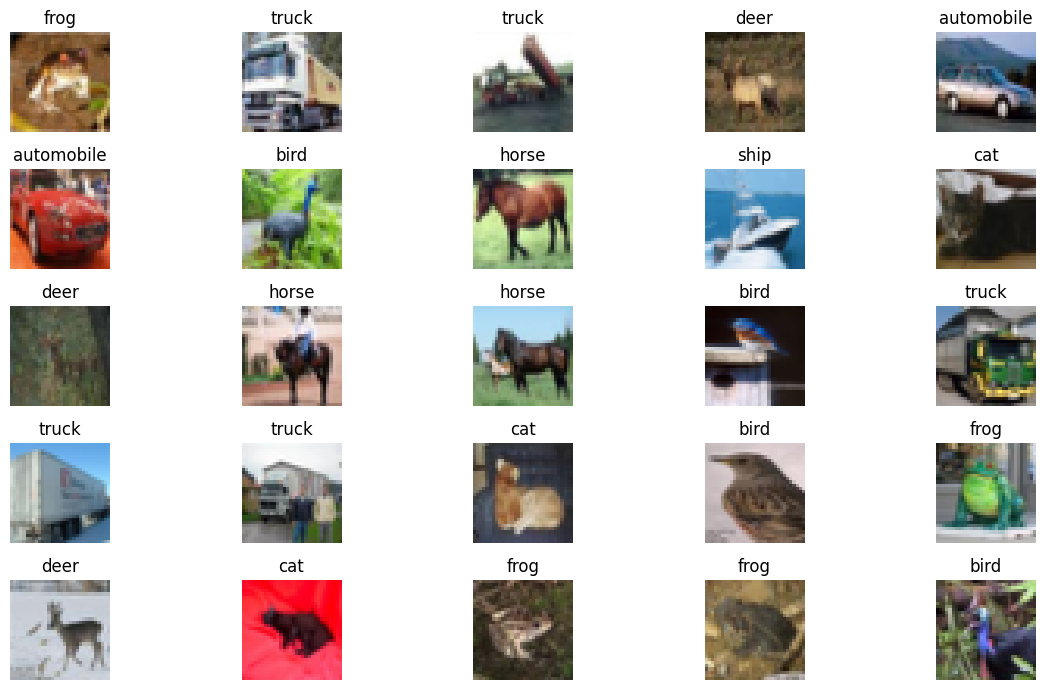

In [4]:
labels = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

plt.figure(figsize = (14,7))

for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i])
  plt.title(labels[y_train[i][0]])
  plt.grid('False')
  plt.axis('off')
  plt.tight_layout()

plt.show()

In [5]:
unique_label = np.unique(y_train)
unique_label

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [6]:
labels_count = pd.Series(y_train.flatten()).value_counts().sort_index()

In [7]:
labels_count

,count
0,5000
1,5000
2,5000
3,5000
4,5000
5,5000
6,5000
7,5000
8,5000
9,5000


In [8]:
labels_count_test = pd.Series(y_test.flatten()).value_counts().sort_index()


/tmp/ipykernel_5280/2430804537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = labels_count.index,y = labels_count.values,palette='muted')


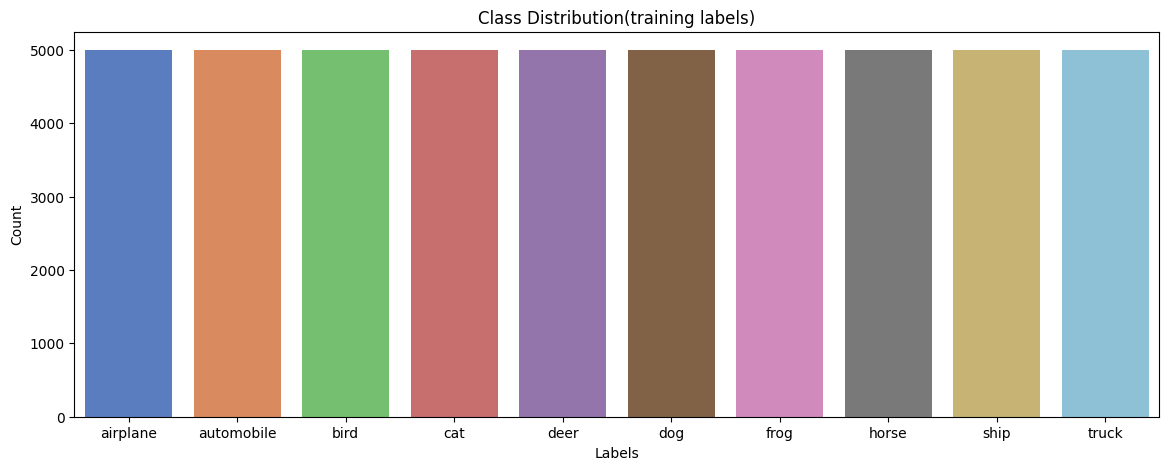

In [9]:
plt.figure(figsize=(14,5))
sns.barplot(x = labels_count.index,y = labels_count.values,palette='muted')
plt.xticks(range(10),labels)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Class Distribution(training labels)')
plt.show()

/tmp/ipykernel_5280/4168424449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = labels_count_test.index,y = labels_count_test.values,palette='muted')


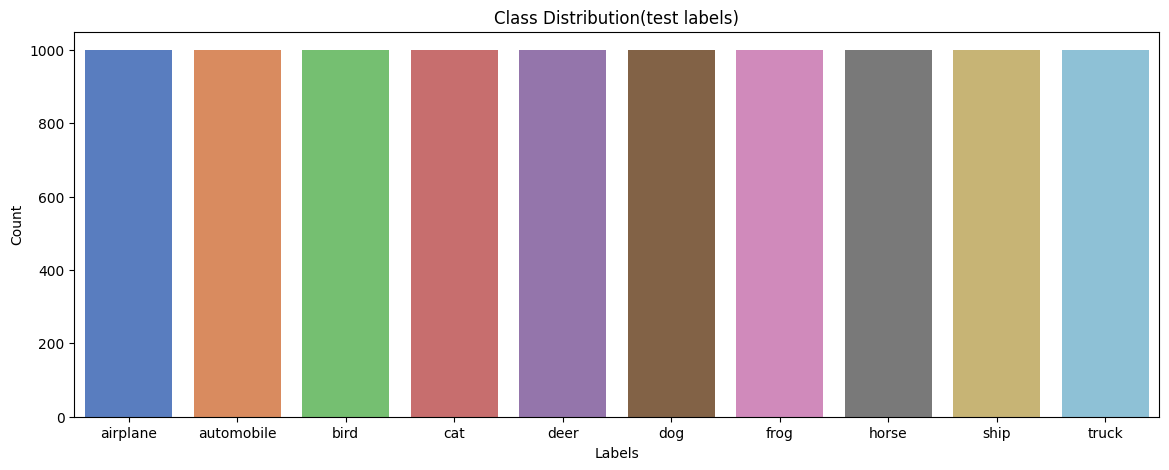

In [10]:
plt.figure(figsize=(14,5))
sns.barplot(x = labels_count_test.index,y = labels_count_test.values,palette='muted')
plt.xticks(range(10),labels)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Class Distribution(test labels)')
plt.show()

**Data preprocessing**

In [11]:
## Normalize our images(0-1)
x_train = x_train/255.0
x_test = x_test/255.0

Model Building(CNN)

In [12]:
## Base Model

base_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

base_model.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = base_model.fit(x_train,y_train,epochs = 10, batch_size= 32, validation_data = (x_test,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4589 - loss: 1.4869 - val_accuracy: 0.5808 - val_loss: 1.1792
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6083 - loss: 1.1104 - val_accuracy: 0.6260 - val_loss: 1.0665
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6616 - loss: 0.9646 - val_accuracy: 0.6648 - val_loss: 0.9600
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6943 - loss: 0.8759 - val_accuracy: 0.6635 - val_loss: 0.9651
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7205 - loss: 0.7918 - val_accuracy: 0.6915 - val_loss: 0.8834
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7413 - loss: 0.7370 - val_accuracy: 0.6888 - val_loss: 0.9211
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7616 - loss: 0.6792 - val_accuracy: 0.6932 - val_loss: 0.9029
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7769 - loss: 0.6297 -

In [14]:
loss,accuracy = base_model.evaluate(x_test,y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7086 - loss: 0.9318
Test Loss: 0.9317691326141357
Test Accuracy: 0.7085999846458435


In [15]:
error = pd.DataFrame(history.history)
error.head()

,accuracy,loss,val_accuracy,val_loss
0,0.45888,1.486920,0.5808,1.179199
1,0.60830,1.110415,0.6260,1.066549
2,0.66160,0.964621,0.6648,0.960049
3,0.69428,0.875946,0.6635,0.965063
4,0.72050,0.791782,0.6915,0.883402


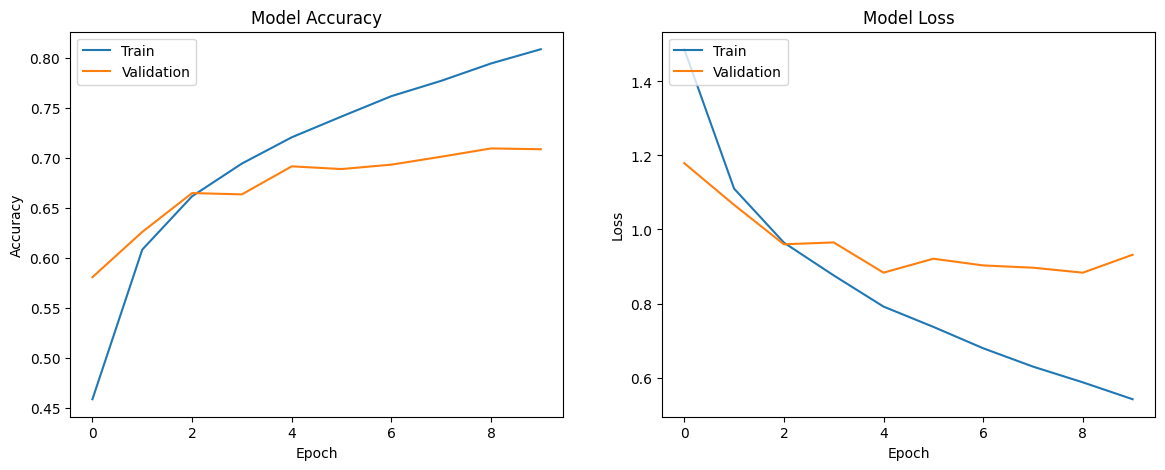

In [16]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(error['accuracy'])
plt.plot(error['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(error['loss'])
plt.plot(error['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')

plt.show()

The validation loss is still high
It decreases upto a certain point then stagnates
That is a sign of overfitting but no very bad

Fix:
1. Tune the number of epochs
2. Tune the batch size (32-64)

*Model 1*

In [17]:
model1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model1.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history1 = model1.fit(x_train,y_train,epochs = 30, batch_size= 32, validation_data = (x_test,y_test))

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4448 - loss: 1.5202 - val_accuracy: 0.5276 - val_loss: 1.3051
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5920 - loss: 1.1552 - val_accuracy: 0.6272 - val_loss: 1.0592
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6442 - loss: 1.0080 - val_accuracy: 0.6523 - val_loss: 0.9815
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6816 - loss: 0.9081 - val_accuracy: 0.6652 - val_loss: 0.9627
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7055 - loss: 0.8394 - val_accuracy: 0.6804 - val_loss: 0.9129
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7261 - loss: 0.7805 - val_accuracy: 0.6930 - val_loss: 0.8948
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7449 - loss: 0.7298 - val_accuracy: 0.7068 - val_loss: 0.8417
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7611 - loss: 0.6832 -

In [19]:
loss,accuracy = model1.evaluate(x_test,y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6926 - loss: 1.6338
Test Loss: 1.6338262557983398
Test Accuracy: 0.6926000118255615


In [20]:
error1 = pd.DataFrame(history1.history)
error1.head()

,accuracy,loss,val_accuracy,val_loss
0,0.44484,1.520157,0.5276,1.305070
1,0.59198,1.155224,0.6272,1.059154
2,0.64424,1.007959,0.6523,0.981540
3,0.68164,0.908140,0.6652,0.962659
4,0.70554,0.839436,0.6804,0.912886


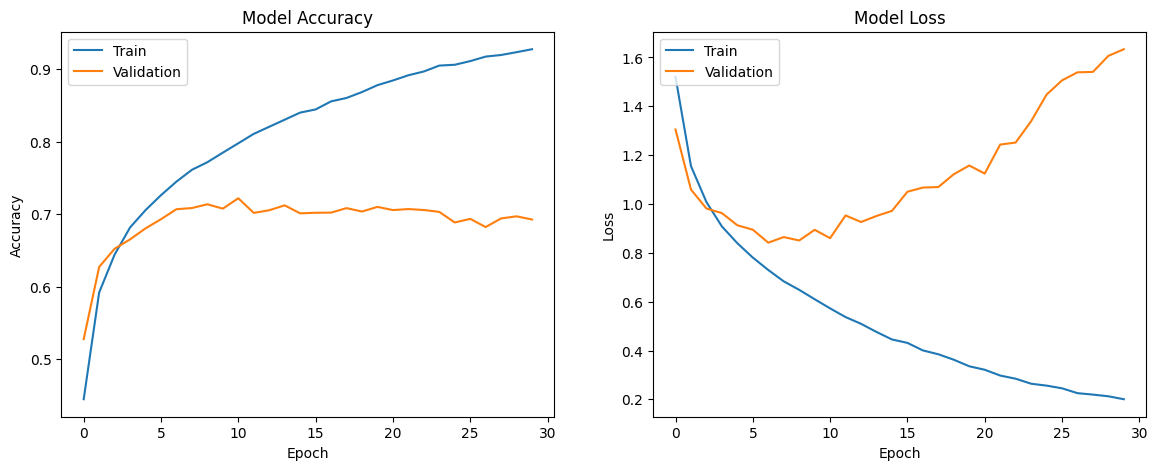

In [21]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(error1['accuracy'])
plt.plot(error1['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(error1['loss'])
plt.plot(error1['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')

plt.show()

Observe that the validation accuracy increase steadily and stagnates at around 0.7

The validation loss decreses steadily until a certain number of epochs where it start diverging

Clearly our model is overfitting

Fix: Introduce Regularization
1. Batch Normalization
2. Dropout
3. Early stopping

*Model 2*

In [22]:
model2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding = 'same', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding = 'same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding = 'same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')
])

model2.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 423,722 (1.62 MB)

 Trainable params: 422,314 (1.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history2 = model2.fit(x_train,y_train,epochs =50, batch_size= 64, validation_data = (x_test,y_test),callbacks=[early_stop])

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.4523 - loss: 1.5515 - val_accuracy: 0.5469 - val_loss: 1.2864
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6204 - loss: 1.0622 - val_accuracy: 0.6728 - val_loss: 0.9473
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6921 - loss: 0.8725 - val_accuracy: 0.6871 - val_loss: 0.9219
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7308 - loss: 0.7694 - val_accuracy: 0.7452 - val_loss: 0.7435
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7554 - loss: 0.6949 - val_accuracy: 0.7745 - val_loss: 0.6533
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7761 - loss: 0.6397 - val_accuracy: 0.7834 - val_loss: 0.6276
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7931 - loss: 0.5937 - val_accuracy: 0.7831 - val_loss: 0.6355
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8053 - loss: 0.5600 - val_accuracy: 

In [24]:
loss,accuracy = model2.evaluate(x_test,y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8211 - loss: 0.5354
Test Loss: 0.5354053974151611
Test Accuracy: 0.8210999965667725


In [25]:
error2 = pd.DataFrame(history2.history)
error1.head()

,accuracy,loss,val_accuracy,val_loss
0,0.44484,1.520157,0.5276,1.305070
1,0.59198,1.155224,0.6272,1.059154
2,0.64424,1.007959,0.6523,0.981540
3,0.68164,0.908140,0.6652,0.962659
4,0.70554,0.839436,0.6804,0.912886


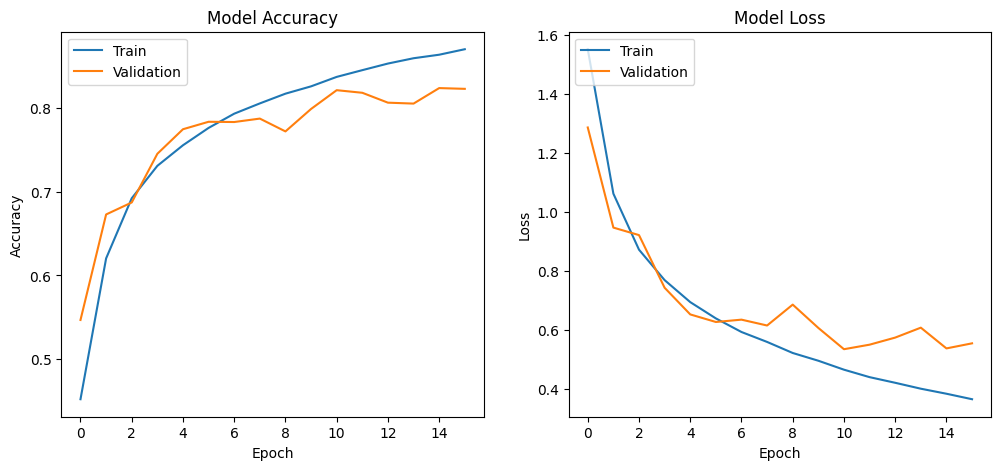

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(error2['accuracy'])
plt.plot(error2['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(error2['loss'])
plt.plot(error2['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc = 'upper left')

plt.show()

Observe

validation accuracy increases but stagnates at around 0.80
Validation loss decreases but stagnates at around 0.60

There is significant improvement in the model

Model Evaluation

In [27]:
from sklearn.metrics import confusion_matrix,classification_report

In [28]:
y_pred = model2.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)

y_test = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [29]:
print(y_test[:10])
print(y_pred[:10])

[3 8 8 0 6 6 1 6 3 1]
[3 8 8 8 6 6 1 6 3 1]


In [30]:
print(classification_report(y_test,y_pred,labels=range(10),target_names=labels))

              precision    recall  f1-score   support

    airplane       0.86      0.81      0.84      1000
  automobile       0.92      0.91      0.91      1000
        bird       0.78      0.74      0.76      1000
         cat       0.71      0.61      0.65      1000
        deer       0.80      0.81      0.80      1000
         dog       0.74      0.73      0.74      1000
        frog       0.81      0.90      0.85      1000
       horse       0.87      0.87      0.87      1000
        ship       0.83      0.94      0.88      1000
       truck       0.88      0.89      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



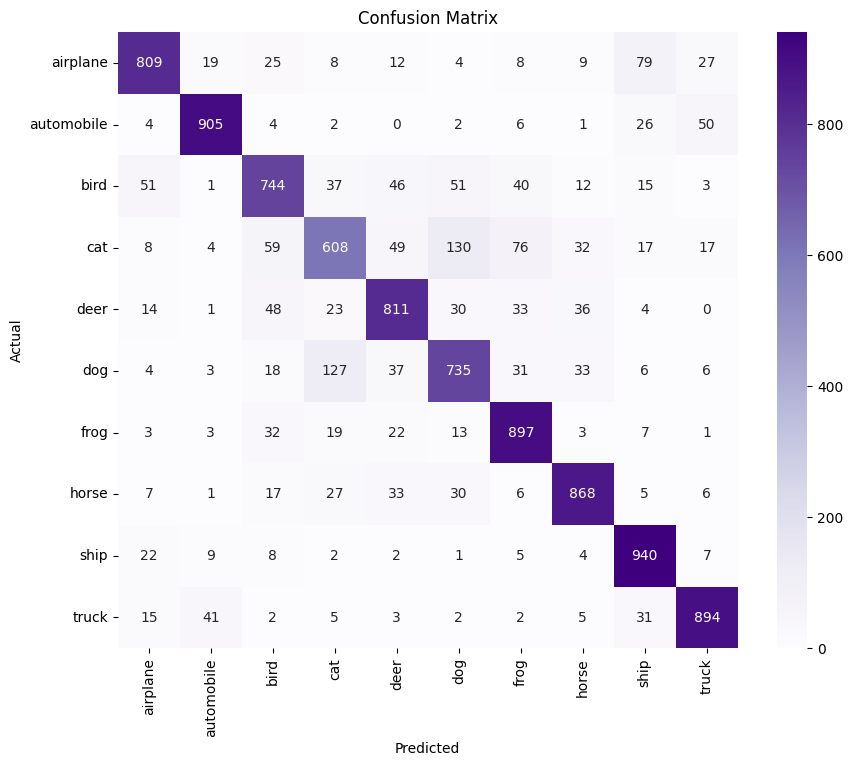

In [31]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

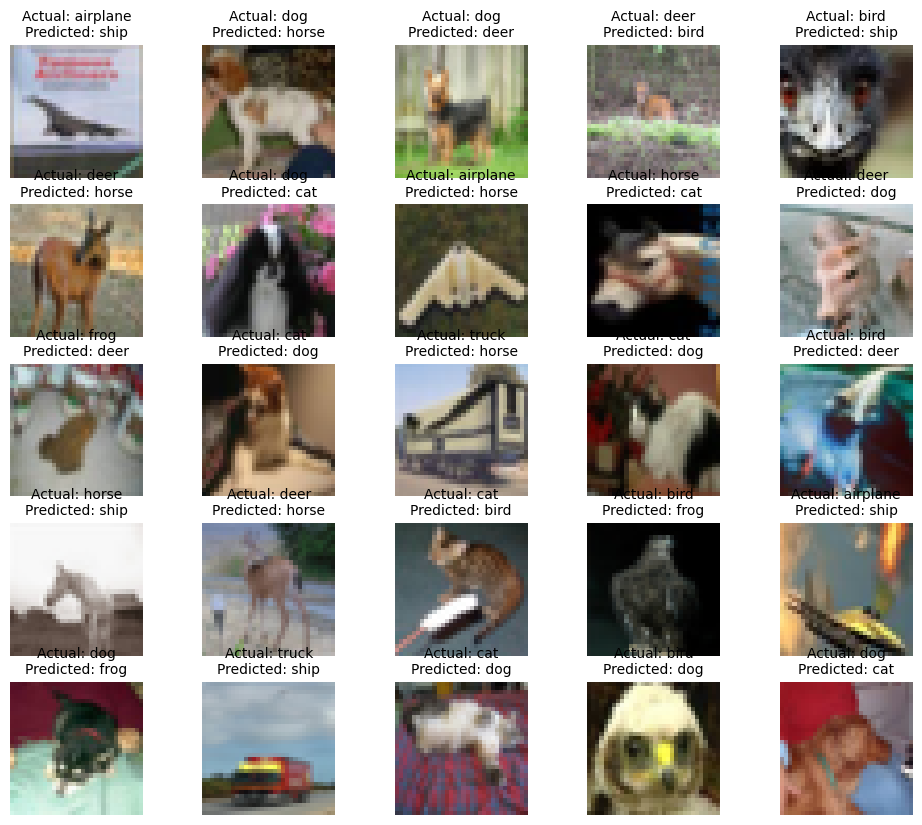

In [32]:
missclassifications = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12,10))

for i, index in enumerate(missclassifications[:25]):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[index])
  plt.title(f"Actual: {labels[y_test[index]]}\nPredicted: {labels[y_pred[index]]}", fontsize = 10)
  plt.axis('off')


plt.show()

Prediction of an external image(Bird)

In [48]:
from tensorflow.keras.utils import load_img, img_to_array

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

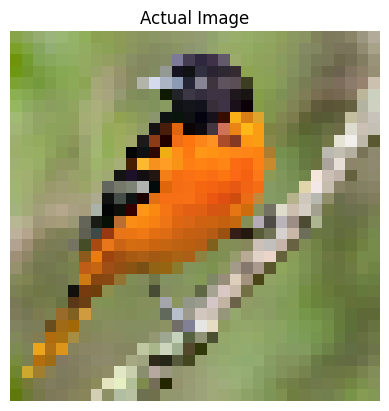

In [50]:
image_path = '/content/beautiful_bird.webp'

img = load_img(image_path,target_size = (32,32))

plt.imshow(img)
plt.title('Actual Image')
plt.axis('off')

In [54]:
## Image preprocessing
img_array = img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)

In [55]:
prediction = model2.predict(img_array)
predicted_label = np.argmax(prediction)
print("predicted_label:", labels[predicted_label])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
predicted_label: bird


In [56]:
for i,prob in enumerate(prediction[0]):
  print(f"{labels[i]}: {prob*100:.2f}%")

airplane: 9.44%
automobile: 2.72%
bird: 74.19%
cat: 0.93%
deer: 0.81%
dog: 3.52%
frog: 5.36%
horse: 0.82%
ship: 1.28%
truck: 0.93%


Our model gave a correct prediction of a bird.

User Interface To Upload Images and get
predictions from the model

In [57]:
## import libraries
import gradio as gr
from PIL import Image

In [58]:
## Image preprocessing

def preprocess_image(img):
  img = img.resize((32,32))
  img_array = img_to_array(img)
  img_array = img_array/255.0
  img_array = np.expand_dims(img_array,axis=0)

  return img_array

In [59]:
## Pred Function
def predict_image(img):
  img_array = preprocess_image(img)
  prediction = model2.predict(img_array)
  predicted_index = np.argmax(prediction)

  predicted_label = labels[predicted_index]

  probabilities = {labels[i]: float(prediction[0][i]) for i in range(10)}

  return predicted_label, probabilities

In [63]:
## Gradio interface
interface = gr.Interface(
    fn = predict_image,
    inputs = gr.Image(type='pil'),
    outputs = [
               gr.Text(label='Predicted Label'),
               gr.Label(num_top_classes=5,label='Class Probabilities')
    ],

    title = 'CIFAR-10 Image Classifier',
    description = 'Upload an image and the model will classifier it into their respective CIFAR category',

)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://473ce3b403ad212da2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
